# Detecção de Folhas Saudáveis e Danificadas
Neste projeto, o objetivo é identificar automaticamente as áreas saudáveis e danificadas de uma
folha a partir de uma imagem real. Ao final, o sistema deve apresentar as regiões segmentadas de
forma visual, evidenciando o estado da folha de maneira clara e interpretável.



In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')  

import funcoes 

import importlib
importlib.reload(funcoes)



<module 'funcoes' from 'c:\\Users\\dalto\\OneDrive\\Documentos\\Unifor\\Semestre 8\\ProcessamentoDigitalImagem\\AV2\\Projeto3_Deteccao_Folhas_Saudaveis\\..\\funcoes.py'>

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

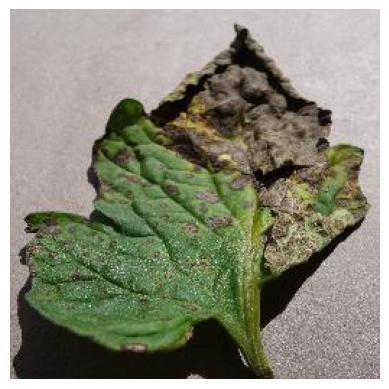

In [ ]:
# Carrega a imagem
img1_rbg = funcoes.carregar_imagem("projeto_3/img_folha_1.JPG", "rgb")


In [5]:

# Filtro de mediana
img_mediana = cv2.medianBlur(img1_rbg, 3)

img_hsv = cv2.cvtColor(img_mediana, cv2.COLOR_RGB2HSV)

# Mascara verde
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
mascara_verde = cv2.inRange(img_hsv, lower_green, upper_green)
parte_verde = cv2.bitwise_and(img_mediana, img_mediana, mask=mascara_verde)

# Mascara escura
lower_dark = np.array([0, 10, 0])
upper_dark = np.array([35, 255, 130])
mascara_dark  = cv2.inRange(img_hsv, lower_dark, upper_dark)
parte_dark  = cv2.bitwise_and(img_mediana, img_mediana, mask=mascara_dark)

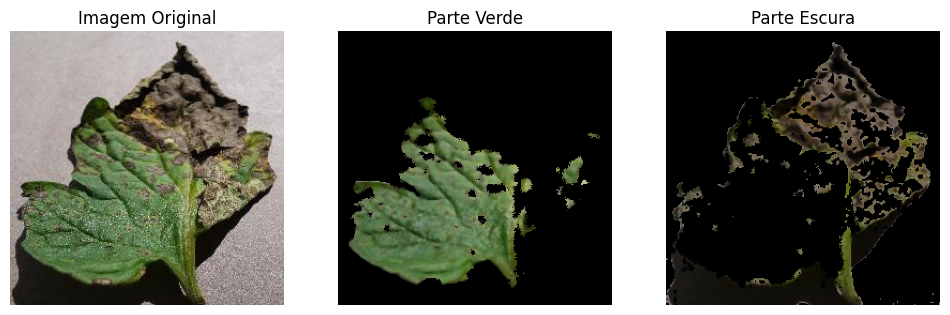

In [7]:
# Vizualização das imagens
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
funcoes.exibir_imagem(img1_rbg, "Imagem Original")
plt.subplot(1, 3, 2)
funcoes.exibir_imagem(parte_verde, "Parte Verde")
plt.subplot(1, 3, 3)
funcoes.exibir_imagem(parte_dark, "Parte Escura")

plt.show()